# MBO 2D Dose Maps: AIC-144 then CCB

This notebook reproduces PDF-like 2D dose/signal views for MBO foils with a style
similar to:
- page 11 of `2_mbo_match_aic144_1_2.pdf` (AIC-144),
- page 19 of `7_mbo_background_subtraction_merge_ccb_2026-03-17_2026-03-19.pdf` (CCB).

Order of plots:
1. **AIC-144** merged foils (match output)
2. **CCB** merged foils (background-subtraction merge output)

Both plots use the same visual language: white-green-red colormap, black isosignal
contours, contour labels, circle overlays, and center markers.

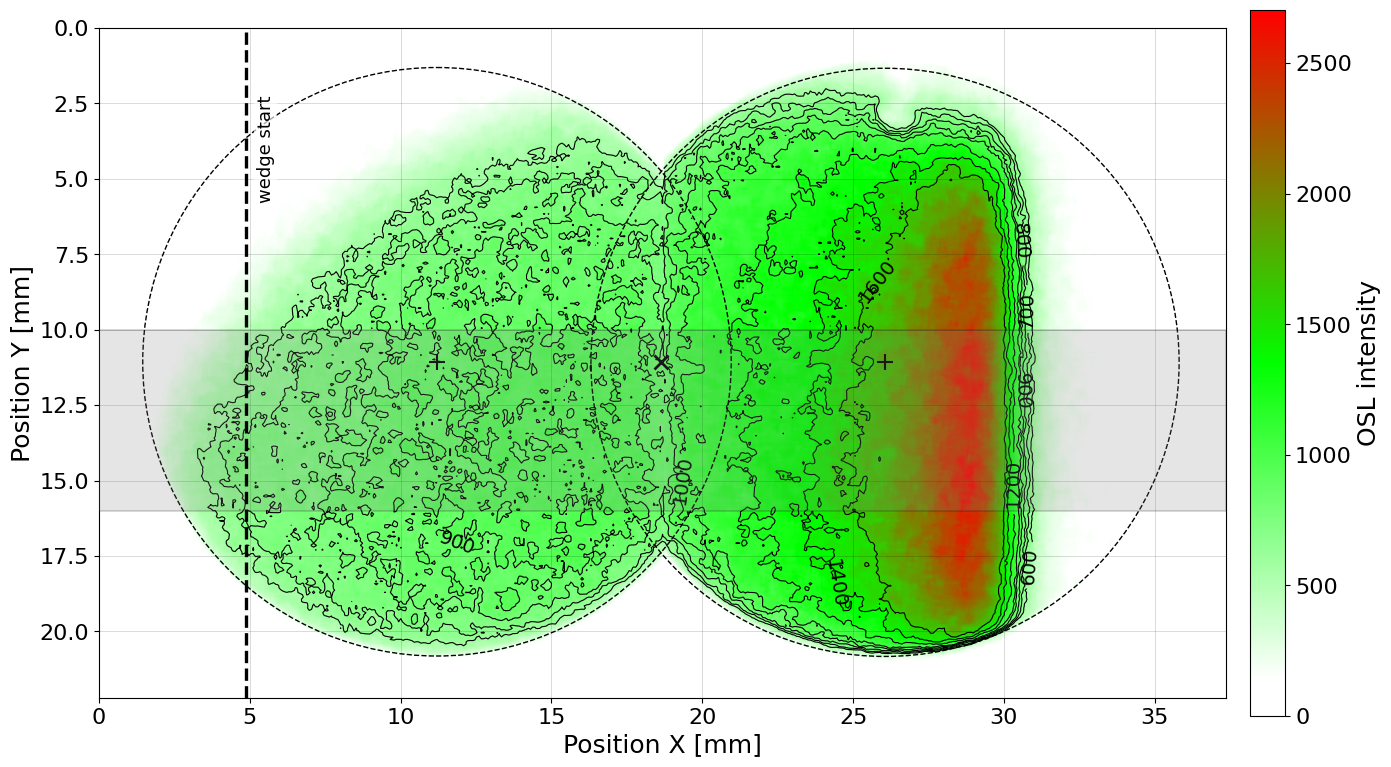

Loaded AIC NPZ: /home/grzanka/workspace/osl_mb_foils/output/pub2026/mbo/data/merged_foils_1_2.npz
AIC image shape: (300, 505), vmax=2704.0, MC R90=24.515 mm


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# Resolve repository root from current working directory.
repo_root = Path.cwd()
if not (repo_root / "notebooks" / "pub_something_2026").exists():
    for parent in repo_root.parents:
        if (parent / "notebooks" / "pub_something_2026").exists():
            repo_root = parent
            break

# Inputs from previously generated pipelines.
data_root = repo_root / "output" / "pub2026" / "mbo" / "data"
aic_npz_path = data_root / "merged_foils_1_2.npz"
ccb_npz_path = data_root / "mbo_bg_sub_merge_ccb_2026-03-17_2026-03-19.npz"

# MC profiles used in 1D notebooks for exact distal-90 ranges.
mc_root = repo_root / "notebooks" / "pub_something_2026" / "mc"
mc_aic_file = mc_root / "mc_aic144_big.csv"
mc_ccb_file = mc_root / "mc_ccb_big.csv"

for f in (aic_npz_path, ccb_npz_path, mc_aic_file, mc_ccb_file):
    if not f.exists():
        raise FileNotFoundError(f"Missing input file: {f}")

# Adjustable plotting parameters.
AIC_CONTOUR_LEVELS = [600, 700, 800, 900, 1000, 1200, 1400, 1600]
CCB_SCENARIO_KEY = "scenario_b_merged_opt"
CCB_CONTOUR_LEVELS = [600, 700, 800, 900, 1000, 1200, 1400, 1600]
FIGSIZE = (14, 8)

# Stripe used for MBO profile extraction in 1D notebooks/pipelines.
PROFILE_STRIPE_Y_MIN_MM = 10.0
PROFILE_STRIPE_Y_MAX_MM = 16.0
STRIPE_FILL_ALPHA = 0.20

# Label placement for wedge-start marker.
WEDGE_START_LABEL_Y_MM = 4.0

# Match the font scale used by 1D plotting notebooks in this directory.
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
CONTOUR_LABEL_FONTSIZE = 14
COLORBAR_LABEL_FONTSIZE = 18
COLORBAR_TICK_FONTSIZE = 16

def white_green_red_cmap(white_threshold=0.05):
    return LinearSegmentedColormap.from_list(
        "white_green_red",
        [
            (0.0, (1, 1, 1, 1)),
            (white_threshold, (1, 1, 1, 1)),
            (0.5, (0, 1, 0, 1)),
            (1.0, (1, 0, 0, 1)),
        ],
    )

def distal_falloff_point(x_mm, y, level=0.9):
    peak_idx = int(np.nanargmax(y))
    for idx in range(peak_idx + 1, len(y)):
        if y[idx] <= level:
            x0, x1 = x_mm[idx - 1], x_mm[idx]
            y0, y1 = y[idx - 1], y[idx]
            if y1 == y0:
                return float(x1)
            fraction = (level - y0) / (y1 - y0)
            return float(x0 + fraction * (x1 - x0))
    raise ValueError(f"Could not find distal {level:.0%} falloff point.")

def mc_distal_90_from_csv(mc_csv_path):
    mc_df = pd.read_csv(mc_csv_path).rename(columns={"depth": "x_mm", "dose": "dose_Gy"})
    mc_df = mc_df[["x_mm", "dose_Gy"]].copy().sort_values("x_mm").reset_index(drop=True)
    y = mc_df["dose_Gy"].to_numpy(dtype=float)
    y_rel = y / np.nanmax(y)
    x = mc_df["x_mm"].to_numpy(dtype=float)
    return distal_falloff_point(x, y_rel, level=0.9)

def profile_from_stripe(merged_image, px, y_min_mm, y_max_mm):
    py_min = int(y_min_mm / px)
    py_max = int(y_max_mm / px)
    py_min = max(0, min(py_min, merged_image.shape[0] - 1))
    py_max = max(py_min + 1, min(py_max, merged_image.shape[0]))

    prof_raw = np.nanmean(merged_image[py_min:py_max, :].astype(float), axis=0)
    prof = np.nan_to_num(prof_raw, nan=0.0)
    if np.nanmax(prof) > 0:
        prof = prof / np.nanmax(prof)
    x_mm = np.arange(merged_image.shape[1]) * px
    return x_mm, prof

def plot_isosignal_2d(
    merged_image,
    left_circle,
    right_circle,
    px,
    contour_levels,
    vmax=None,
    stripe_y_min_mm=None,
    stripe_y_max_mm=None,
    wedge_start_offset_from_r90_mm=None,
):
    if vmax is None:
        vmax = float(np.nanpercentile(merged_image, 99.5))

    h, w = merged_image.shape
    extent = [0, w * px, h * px, 0]
    x_mm = np.linspace(0, w * px, w)
    y_mm = np.linspace(0, h * px, h)
    data_for_contour = np.nan_to_num(merged_image.astype(float), nan=0.0)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    im = ax.imshow(
        np.ma.masked_invalid(merged_image),
        cmap=white_green_red_cmap(),
        vmin=0.0,
        vmax=vmax,
        extent=extent,
        aspect="equal",
    )

    cs = ax.contour(
        x_mm,
        y_mm,
        data_for_contour,
        levels=contour_levels,
        colors="black",
        linewidths=0.8,
    )
    ax.clabel(cs, inline=True, fontsize=CONTOUR_LABEL_FONTSIZE, fmt="%.0f")

    if stripe_y_min_mm is not None and stripe_y_max_mm is not None:
        stripe_h = stripe_y_max_mm - stripe_y_min_mm
        if stripe_h > 0:
            stripe = Rectangle(
                (0.0, stripe_y_min_mm),
                w * px,
                stripe_h,
                facecolor="gray",
                edgecolor="black",
                linewidth=1.1,
                alpha=STRIPE_FILL_ALPHA,
                zorder=6,
            )
            ax.add_patch(stripe)

    if (
        wedge_start_offset_from_r90_mm is not None
        and stripe_y_min_mm is not None
        and stripe_y_max_mm is not None
    ):
        profile_x_mm, profile_y = profile_from_stripe(
            merged_image, px, stripe_y_min_mm, stripe_y_max_mm
        )
        r90_mm = distal_falloff_point(profile_x_mm, profile_y, level=0.9)
        wedge_start_x_mm = r90_mm - wedge_start_offset_from_r90_mm
        ax.axvline(
            wedge_start_x_mm,
            color="black",
            linestyle="--",
            linewidth=2.4,
            zorder=7,
        )
        ax.text(
            wedge_start_x_mm + 0.35,
            WEDGE_START_LABEL_Y_MM,
            "wedge start",
            rotation=90,
            va="center",
            ha="left",
            fontsize=13,
            color="black",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 2.0},
            zorder=8,
        )

    for cx, cy, r in (left_circle, right_circle):
        ax.add_patch(plt.Circle((cx * px, cy * px), r * px, color="black", fill=False, lw=1, ls="--"))
        ax.plot(cx * px, cy * px, "k+", ms=12, mew=1.5)

    mid_x_mm = (left_circle[0] + right_circle[0]) / 2 * px
    mid_y_mm = (left_circle[1] + right_circle[1]) / 2 * px
    ax.plot(mid_x_mm, mid_y_mm, "kx", ms=10, mew=2)

    ax.set_xlabel("Position X [mm]", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("Position Y [mm]", fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.grid(True, color="k", alpha=0.2, lw=0.5)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("OSL intensity", fontsize=COLORBAR_LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE)

    fig.tight_layout()
    return fig

# Distal 90% points from exact MC simulations used in 1D notebooks.
mc_aic_r90_mm = mc_distal_90_from_csv(mc_aic_file)
mc_ccb_r90_mm = mc_distal_90_from_csv(mc_ccb_file)

# ------------------------------------------------------------------
# 1) AIC-144 (first)
# ------------------------------------------------------------------
aic_npz = np.load(aic_npz_path)
aic_img = aic_npz["merged_image_opt"].astype(float)
aic_px = float(aic_npz["pixel_size_mm"])
aic_left_circle = (
    float(aic_npz["left_circle_opt_x"]),
    float(aic_npz["left_circle_opt_y"]),
    float(aic_npz["left_circle_opt_r"]),
)
aic_right_circle = (
    float(aic_npz["right_circle_opt_x"]),
    float(aic_npz["right_circle_opt_y"]),
    float(aic_npz["right_circle_opt_r"]),
)
aic_vmax = float(np.nanmax(aic_img))

fig_aic = plot_isosignal_2d(
    aic_img,
    aic_left_circle,
    aic_right_circle,
    aic_px,
    contour_levels=AIC_CONTOUR_LEVELS,
    vmax=aic_vmax,
    stripe_y_min_mm=PROFILE_STRIPE_Y_MIN_MM,
    stripe_y_max_mm=PROFILE_STRIPE_Y_MAX_MM,
    wedge_start_offset_from_r90_mm=mc_aic_r90_mm,
)
plt.show()

print(f"Loaded AIC NPZ: {aic_npz_path}")
print(f"AIC image shape: {aic_img.shape}, vmax={aic_vmax:.1f}, MC R90={mc_aic_r90_mm:.3f} mm")

/tmp/ipykernel_141287/2270314947.py:89: RuntimeWarning: Mean of empty slice
  prof_raw = np.nanmean(merged_image[py_min:py_max, :].astype(float), axis=0)


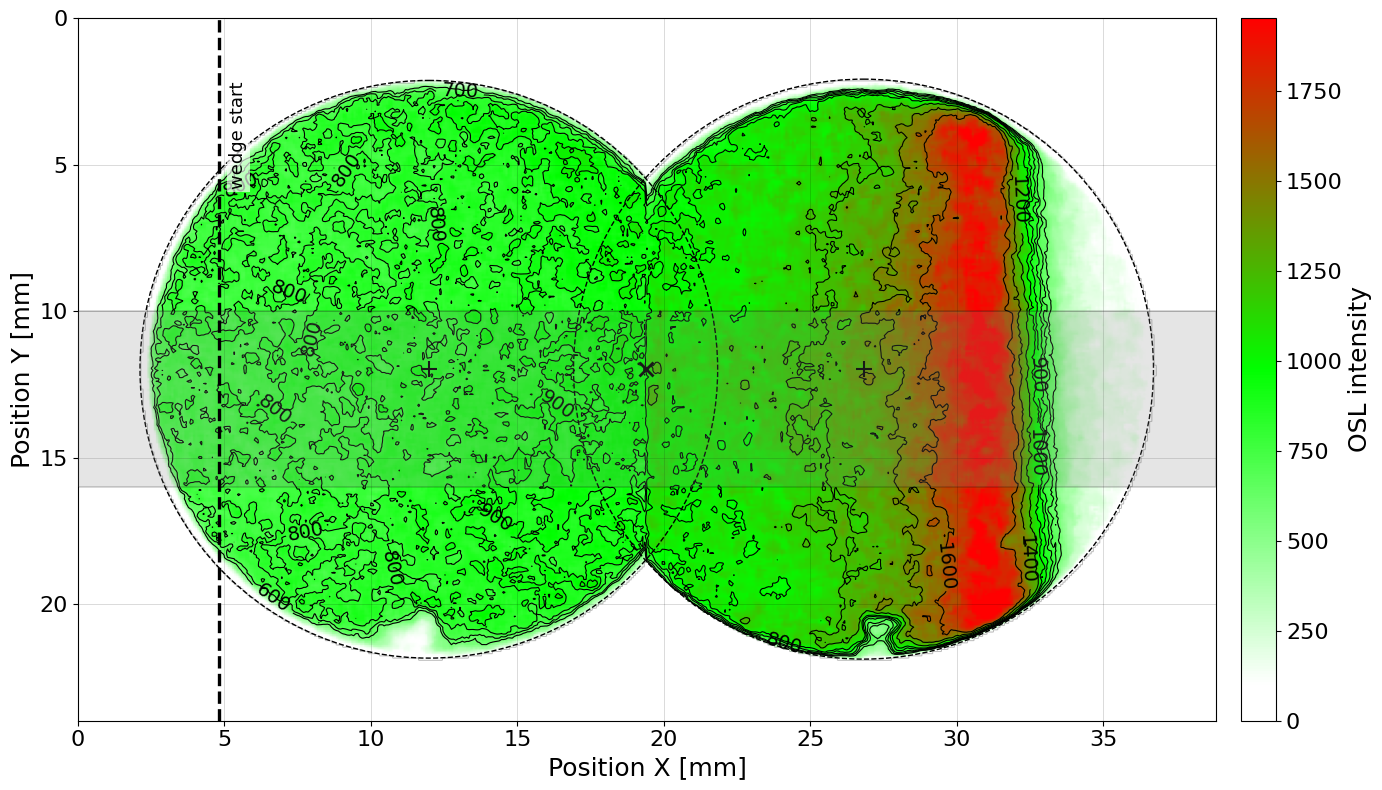

Loaded CCB NPZ: /home/grzanka/workspace/osl_mb_foils/output/pub2026/mbo/data/mbo_bg_sub_merge_ccb_2026-03-17_2026-03-19.npz
CCB image shape: (324, 525), vmax=1952.50, scenario=scenario_b_merged_opt, MC R90=26.784 mm


In [5]:
# ------------------------------------------------------------------
# 2) CCB (second, page-19-like scenario)
# ------------------------------------------------------------------
ccb_npz = np.load(ccb_npz_path)
if CCB_SCENARIO_KEY not in ccb_npz:
    raise KeyError(f"{CCB_SCENARIO_KEY} not found in {ccb_npz_path.name}")

ccb_img = ccb_npz[CCB_SCENARIO_KEY].astype(float)
ccb_px = float(ccb_npz["pixel_size_mm"])
prefix = CCB_SCENARIO_KEY.replace("_merged_opt", "")
ccb_left_circle = (
    float(ccb_npz[f"{prefix}_left_circle_opt_x"]),
    float(ccb_npz[f"{prefix}_left_circle_opt_y"]),
    float(ccb_npz[f"{prefix}_left_circle_opt_r"]),
)
ccb_right_circle = (
    float(ccb_npz[f"{prefix}_right_circle_opt_x"]),
    float(ccb_npz[f"{prefix}_right_circle_opt_y"]),
    float(ccb_npz[f"{prefix}_right_circle_opt_r"]),
)

# Keep CCB color scale positive for dose-like visualisation.
ccb_vmax = float(np.nanpercentile(ccb_img, 99.5))

fig_ccb = plot_isosignal_2d(
    ccb_img,
    ccb_left_circle,
    ccb_right_circle,
    ccb_px,
    contour_levels=CCB_CONTOUR_LEVELS,
    vmax=ccb_vmax,
    stripe_y_min_mm=PROFILE_STRIPE_Y_MIN_MM,
    stripe_y_max_mm=PROFILE_STRIPE_Y_MAX_MM,
    wedge_start_offset_from_r90_mm=mc_ccb_r90_mm,
)
plt.show()

print(f"Loaded CCB NPZ: {ccb_npz_path}")
print(f"CCB image shape: {ccb_img.shape}, vmax={ccb_vmax:.2f}, scenario={CCB_SCENARIO_KEY}, MC R90={mc_ccb_r90_mm:.3f} mm")

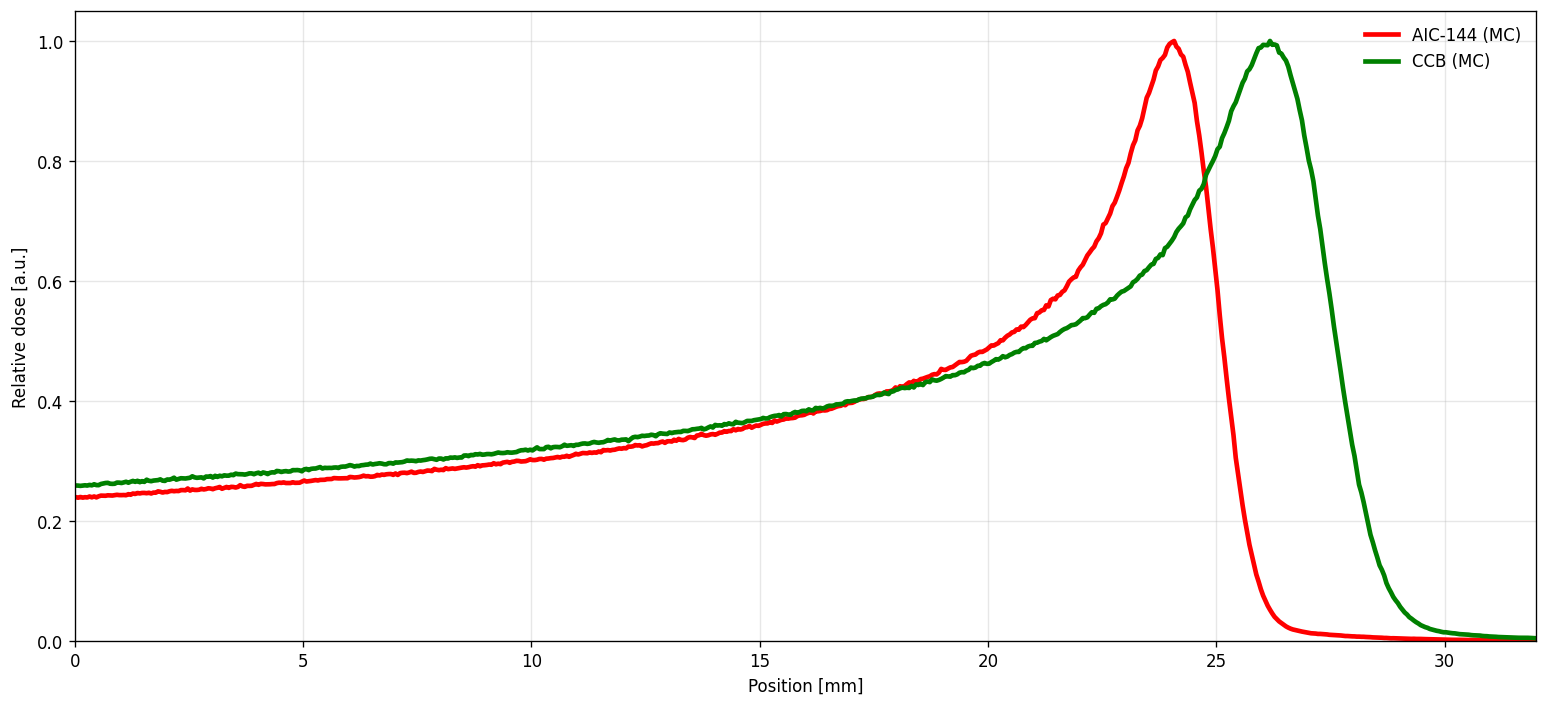

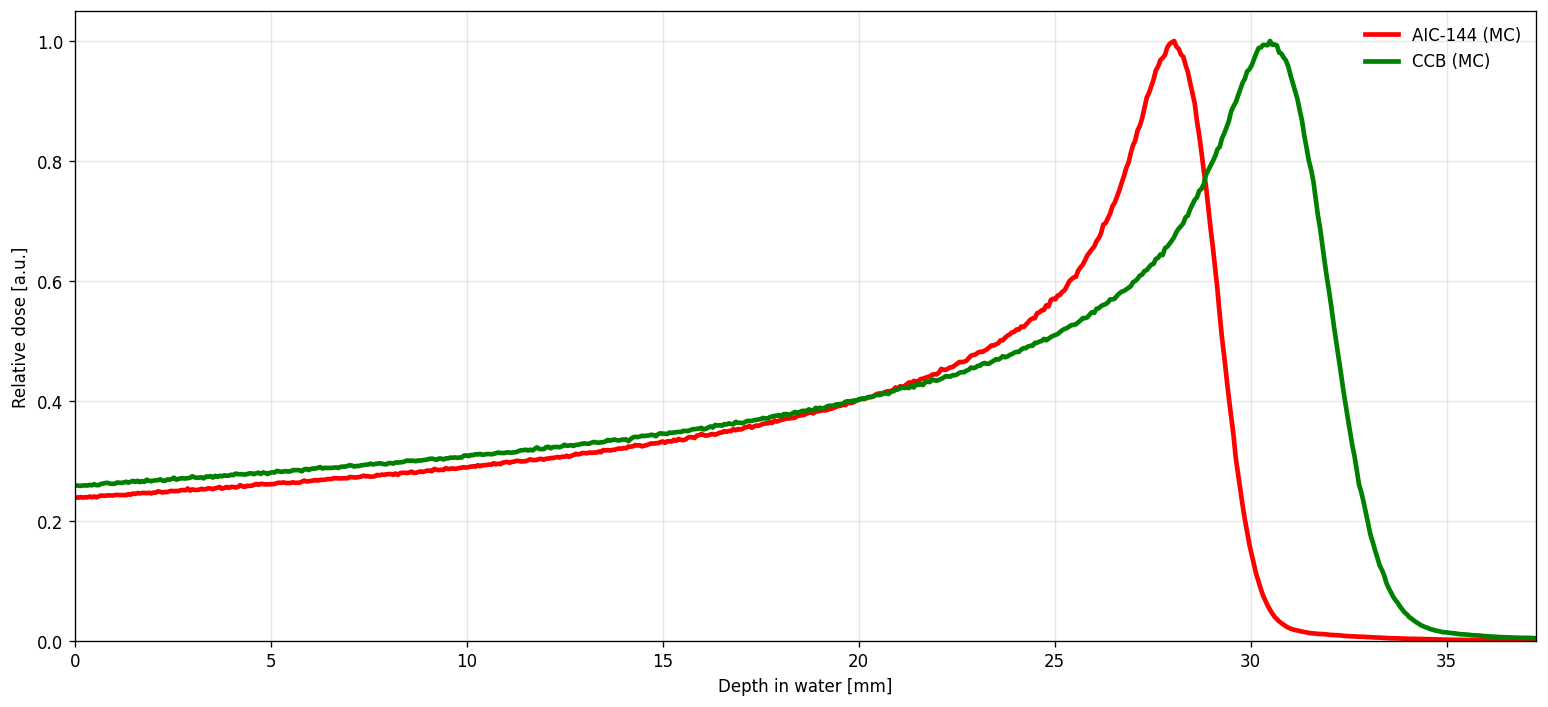

In [6]:
# 3) Dose profiles after wedge (MC): AIC-144 vs CCB
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

WATER_EQ_FACTOR = 1.165

# Resolve repository root (works even if this cell is run standalone).
repo_root_local = Path.cwd()
if not (repo_root_local / "notebooks" / "pub_something_2026").exists():
    for parent in repo_root_local.parents:
        if (parent / "notebooks" / "pub_something_2026").exists():
            repo_root_local = parent
            break

mc_root = repo_root_local / "notebooks" / "pub_something_2026" / "mc"
mc_ccb_file = mc_root / "mc_ccb_big.csv"
mc_aic_file = mc_root / "mc_aic144_big.csv"

for f in (mc_ccb_file, mc_aic_file):
    if not f.exists():
        raise FileNotFoundError(f"Missing MC file: {f}")

mc_ccb = np.genfromtxt(mc_ccb_file, delimiter=",", names=True, dtype=float)
mc_aic = np.genfromtxt(mc_aic_file, delimiter=",", names=True, dtype=float)

x_ccb = mc_ccb["depth"]
y_ccb = mc_ccb["dose"]
x_aic = mc_aic["depth"]
y_aic = mc_aic["dose"]

# Set to False to plot absolute dose values from MC.
NORMALIZE_TO_MAX = True
if NORMALIZE_TO_MAX:
    y_ccb_plot = y_ccb / np.nanmax(y_ccb)
    y_aic_plot = y_aic / np.nanmax(y_aic)
    y_label = "Relative dose [a.u.]"
else:
    y_ccb_plot = y_ccb
    y_aic_plot = y_aic
    y_label = "Dose [a.u.]"

fig, ax = plt.subplots(figsize=(13, 6), dpi=120)
ax.plot(x_aic, y_aic_plot, color="red", linewidth=2.8, label="AIC-144 (MC)")
ax.plot(x_ccb, y_ccb_plot, color="green", linewidth=2.8, label="CCB (MC)")
ax.set_xlim(0, 32)
ax.set_ylim(0, None)

ax.set_xlabel("Position [mm]")
ax.set_ylabel(y_label)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

x_ccb_water = x_ccb * WATER_EQ_FACTOR
x_aic_water = x_aic * WATER_EQ_FACTOR

fig, ax = plt.subplots(figsize=(13, 6), dpi=120)
ax.plot(x_aic_water, y_aic_plot, color="red", linewidth=2.8, label="AIC-144 (MC)")
ax.plot(x_ccb_water, y_ccb_plot, color="green", linewidth=2.8, label="CCB (MC)")
ax.set_xlim(0, 32 * WATER_EQ_FACTOR)
ax.set_ylim(0, None)

ax.set_xlabel("Depth in water [mm]")
ax.set_ylabel(y_label)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()